In [1]:
!git clone https://github.com/DhanyasriChilaka/es335-ml-assignment-1

Cloning into 'es335-ml-assignment-1'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 36 (delta 5), reused 4 (delta 4), pack-reused 28 (from 2)
Receiving objects: 100% (36/36), 22.29 KiB | 11.14 MiB/s, done.
Resolving deltas: 100% (7/7), done.


##Question 2

In [2]:
# %load /content/drive/MyDrive/human+activity+recognition+using+smartphones/CombineScript.py
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
#
#                                   ES335- Machine Learning- Assignment 1
#
# This script combines the data from the UCI HAR Dataset into a more usable format.
# The data is combined into a single csv file for each subject and activity.
# The data is then stored in the Combined folder.
#
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

# Library imports
import pandas as pd
import numpy as np
import os

# Give the path of the test and train folder of UCI HAR Dataset
train_path = "/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/train"
test_path = "/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/test"

# Dictionary of activities. Provided by the dataset.
ACTIVITIES = {
    1: 'WALKING'            ,
    2: 'WALKING_UPSTAIRS'   ,
    3: 'WALKING_DOWNSTAIRS' ,
    4: 'SITTING'            ,
    5: 'STANDING'           ,
    6: 'LAYING'             ,
}

#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
                                        # Combining Traing Data
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

# Load all the accelerometer data
total_acc_x = pd.read_csv(os.path.join(train_path,"Inertial Signals","total_acc_x_train.txt"),delim_whitespace=True,header=None)
total_acc_y = pd.read_csv(os.path.join(train_path,"Inertial Signals","total_acc_y_train.txt"),delim_whitespace=True,header=None)
total_acc_z = pd.read_csv(os.path.join(train_path,"Inertial Signals","total_acc_z_train.txt"),delim_whitespace=True,header=None)


# Read the subject IDs
subject_train = pd.read_csv(os.path.join(train_path,"subject_train.txt"),delim_whitespace=True,header=None)

# Read the labels
y = pd.read_csv(os.path.join(train_path,"y_train.txt"),delim_whitespace=True,header=None)


# Toggle through all the subjects.
for subject in np.unique(subject_train.values):

    sub_idxs = np.where( subject_train.iloc[:,0] == subject )[0]
    labels = y.loc[sub_idxs]

    # Toggle through all the labels.
    for label in np.unique(labels.values):

        # make the folder directory if it does not exist
        if not os.path.exists(os.path.join("Combined","Train",ACTIVITIES[label])):
            os.makedirs(os.path.join("Combined","Train",ACTIVITIES[label]))

        label_idxs = labels[labels.iloc[:,0] == label].index

        accx = []
        accy = []
        accz = []

        for idx in label_idxs:
            if accx is not None:
                accx = np.hstack((accx,total_acc_x.loc[idx][64:]))
                accy = np.hstack((accy,total_acc_y.loc[idx][64:]))
                accz = np.hstack((accz,total_acc_z.loc[idx][64:]))

            else:
                accx = total_acc_x.loc[idx]
                accy = total_acc_y.loc[idx]
                accz = total_acc_z.loc[idx]

        # saving the data into csv file
        data = pd.DataFrame({'accx':accx,'accy':accy,'accz':accz})
        save_path = os.path.join("Combined","Train",ACTIVITIES[label],f"Subject_{subject}.csv")
        data.to_csv(save_path,index=False)

print("Done Combining the training data")


#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
                                        # Combining Test Data
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

# Load all the accelerometer data
total_acc_x = pd.read_csv(os.path.join(test_path,"Inertial Signals","total_acc_x_test.txt"),delim_whitespace=True,header=None)
total_acc_y = pd.read_csv(os.path.join(test_path,"Inertial Signals","total_acc_y_test.txt"),delim_whitespace=True,header=None)
total_acc_z = pd.read_csv(os.path.join(test_path,"Inertial Signals","total_acc_z_test.txt"),delim_whitespace=True,header=None)

# Read the subject IDs
subject_test = pd.read_csv(os.path.join(test_path,"subject_test.txt"),delim_whitespace=True,header=None)

# Read the labels
y = pd.read_csv(os.path.join(test_path,"y_test.txt"),delim_whitespace=True,header=None)

# Toggle through all the subjects.
for subject in np.unique(subject_test.values):

        sub_idxs = np.where( subject_test.iloc[:,0] == subject )[0]
        labels = y.loc[sub_idxs]

        # Toggle through all the labels.
        for label in np.unique(labels.values):

            if not os.path.exists(os.path.join("Combined","Test",ACTIVITIES[label])):
                os.makedirs(os.path.join("Combined","Test",ACTIVITIES[label]))

            label_idxs = labels[labels.iloc[:,0] == label].index

            accx = []
            accy = []
            accz = []
            for idx in label_idxs:
                if accx is not None:
                    accx = np.hstack((accx,total_acc_x.loc[idx][64:]))
                    accy = np.hstack((accy,total_acc_y.loc[idx][64:]))
                    accz = np.hstack((accz,total_acc_z.loc[idx][64:]))

                else:
                    accx = total_acc_x.loc[idx]
                    accy = total_acc_y.loc[idx]
                    accz = total_acc_z.loc[idx]

            # saving the data into csv file
            data = pd.DataFrame({'accx':accx,'accy':accy,'accz':accz})
            save_path = os.path.join("Combined","Test",ACTIVITIES[label],f"Subject_{subject}.csv")
            data.to_csv(save_path,index=False)

print("Done Combining the testing data")
print("Done Combining the data")

#-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

/tmp/ipython-input-620560776.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  total_acc_x = pd.read_csv(os.path.join(train_path,"Inertial Signals","total_acc_x_train.txt"),delim_whitespace=True,header=None)
/tmp/ipython-input-620560776.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  total_acc_y = pd.read_csv(os.path.join(train_path,"Inertial Signals","total_acc_y_train.txt"),delim_whitespace=True,header=None)
/tmp/ipython-input-620560776.py:38: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  total_acc_z = pd.read_csv(os.path.join(train_path,"Inertial Signals","total_acc_z_train.txt"),delim_whitespace=True,header=None)
/tmp/ipython-input-620560776.py:42: FutureWarning: The 'delim_whitespace'

Done Combining the training data


/tmp/ipython-input-620560776.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  total_acc_x = pd.read_csv(os.path.join(test_path,"Inertial Signals","total_acc_x_test.txt"),delim_whitespace=True,header=None)
/tmp/ipython-input-620560776.py:92: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  total_acc_y = pd.read_csv(os.path.join(test_path,"Inertial Signals","total_acc_y_test.txt"),delim_whitespace=True,header=None)
/tmp/ipython-input-620560776.py:93: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  total_acc_z = pd.read_csv(os.path.join(test_path,"Inertial Signals","total_acc_z_test.txt"),delim_whitespace=True,header=None)
/tmp/ipython-input-620560776.py:96: FutureWarning: The 'delim_whitespace' keywo

Done Combining the testing data
Done Combining the data


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset.zip"  # change this
extract_path = "/content/drive/MyDrive/human+activity+recognition+using+smartphones"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

Files extracted to: /content/drive/MyDrive/human+activity+recognition+using+smartphones


In [113]:
# %load /content/drive/MyDrive/human+activity+recognition+using+smartphones/MakeDataset.py
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
#
#                                   ES335- Machine Learning- Assignment 1
#
# This file is used to create the dataset for the mini-project. The dataset is created by reading the data from
# the Combined folder. The data is then split into training, testing, and validation sets. This split is supposed
# to be used for all the modeling purposes.
#
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

# Library imports
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import os

# Constants
time = 10
offset = 100
folders = ["LAYING","SITTING","STANDING","WALKING","WALKING_DOWNSTAIRS","WALKING_UPSTAIRS"]
classes = {"WALKING":1,"WALKING_UPSTAIRS":2,"WALKING_DOWNSTAIRS":3,"SITTING":4,"STANDING":5,"LAYING":6}

combined_dir = os.path.join("Combined")

#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
                                                # Train Dataset
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

X_train=[]
y_train=[]
subject_train = []
dataset_dir = os.path.join(combined_dir,"Train")

for folder in folders:
    files = os.listdir(os.path.join(dataset_dir,folder))

    for file in files:

        df = pd.read_csv(os.path.join(dataset_dir,folder,file),sep=",",header=0)
        df = df[offset:offset+time*50]
        X_train.append(df.values)
        y_train.append(classes[folder])
        subject_id = file.split('.')[0]  # removes '.csv'
        subject_train.append(subject_id)
X_train = np.array(X_train)
y_train = np.array(y_train)
subject_train = np.array(subject_train)

#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
                                                # Test Dataset
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

X_test=[]
y_test=[]
subject_test = []
dataset_dir = os.path.join(combined_dir,"Test")

for folder in folders:
    files = os.listdir(os.path.join(dataset_dir,folder))
    for file in files:

        df = pd.read_csv(os.path.join(dataset_dir,folder,file),sep=",",header=0)
        df = df[offset:offset+time*50]
        X_test.append(df.values)
        y_test.append(classes[folder])
        subject_id = file.split('.')[0]
        subject_test.append(subject_id)
X_test = np.array(X_test)
y_test = np.array(y_test)
subject_test = np.array(subject_test)
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
                                                # Final Dataset
#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

# USE THE BELOW GIVEN DATA FOR TRAINING and TESTING purposes

# concatenate the training and testing data
X = np.concatenate((X_train,X_test))
y = np.concatenate((y_train,y_test))
subjects = np.concatenate((subject_train, subject_test))
# split the data into training and testing sets. Change the seed value to obtain different random splits.
seed = 42
X_train3,X_test3,y_train3,y_test3,subject_train3, subject_test3  = train_test_split(X,y,subjects,test_size=0.3,random_state=seed,stratify=y)

print("Training data shape: ",X_train3.shape)
print("Testing data shape: ",X_test3.shape)

#=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=




Training data shape:  (126, 500, 3)
Testing data shape:  (54, 500, 3)


(126, 500, 3)

# 1.Decision tree construction




##a.raw-accelerometer




In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [93]:
X_train_down = X_train3[: ,::5, :]
X_test_down = X_test3[: ,::5, :]
X_train_down.shape

(126, 34, 3)

#### decision tree

In [75]:
Hartree = DecisionTreeClassifier(random_state=42)

In [94]:
X_train_down_flat = X_train3.reshape(126, -1)
X_test_down_flat = X_test3.reshape(54, -1)

In [95]:
Hartree.fit(X_train_down_flat, y_train3)

DecisionTreeClassifier(random_state=42)

In [96]:
y_pred = Hartree.predict(X_test_down_flat)

#### result

In [97]:
Accuracy1 =  accuracy_score(y_test3, y_pred)
precision1 = precision_score(y_test3, y_pred, average='macro')
recall1 = recall_score(y_test3, y_pred, average='macro')

print("Accuracy:", Accuracy1)
print("Precision:", precision1)
print("Recall:", recall1)

Accuracy: 0.6481481481481481
Precision: 0.6373737373737374
Recall: 0.6481481481481481


#### Confusion matrix



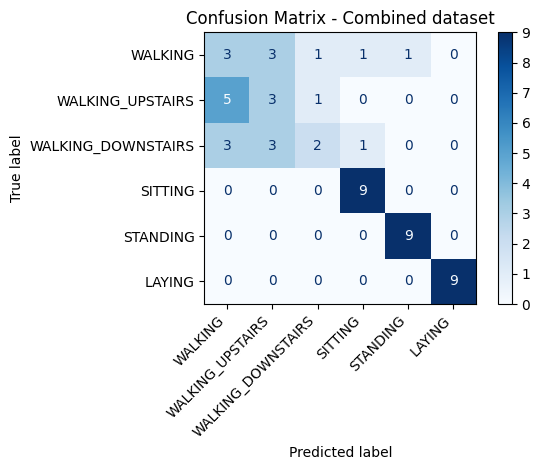

In [98]:

cm = confusion_matrix(y_test3, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"])
display.plot(cmap="Blues")
plt.xticks(rotation=45, ha='right')

plt.title("Confusion Matrix - Combined dataset")
plt.tight_layout()
plt.show()




In [45]:
depths = range(2,9)
accuracies_raw = []
for depth in depths:
  tree_raw = DecisionTreeClassifier(max_depth =depth,random_state = 42)
  tree_raw.fit(X_train_down_flat,y_train3)
  y_predraw = tree_raw.predict(X_test_down_flat)
  acc = accuracy_score(y_test3,y_predraw)
  accuracies_raw.append(acc)

##b.TFSEL

In [16]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.9 MB/s eta 0:00:00


/tmp/ipython-input-868843867.py:26: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-868843867.py:26: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-868843867.py:26: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-868843867.py:26: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-868843867.py:26: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-868843867.py:26: UserWarning: Using default sampling frequenc

Extracted TSFEL features shape: (126, 135)
PCA output shape: (126, 2)


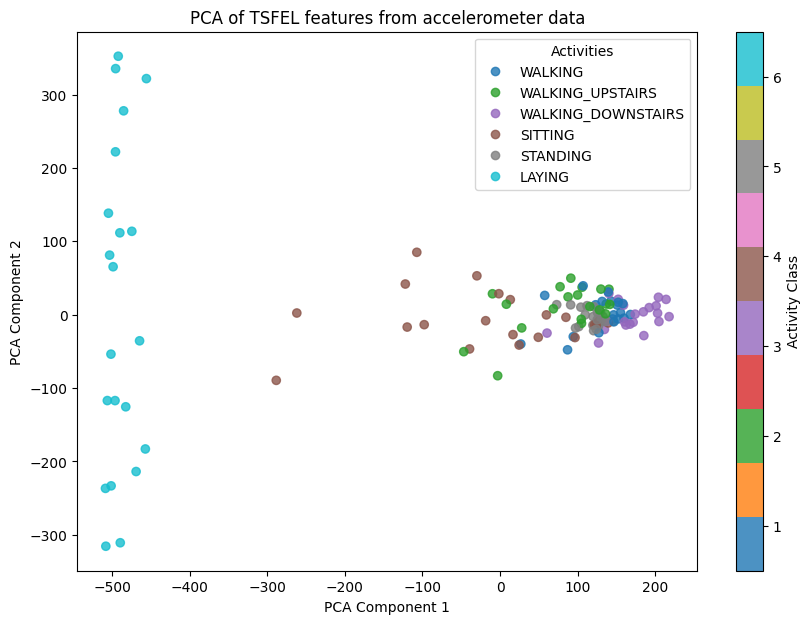

In [17]:
import tsfel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


cfg = tsfel.get_features_by_domain()


selected_domains = ['statistical', 'temporal']
cfg_selected = {k: v for k, v in cfg.items() if k in selected_domains}

# 2. Extract TSFEL features for all samples (all 3 axes)
ts_features = []

for sample in X_train3:
    # Extract features axis-wise and concatenate
    feat_list = []
    for axis in range(3):
        ts = sample[:, axis]
        feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
        feat_list.append(feat.values.flatten())
    combined_features = np.hstack(feat_list)
    ts_features.append(combined_features)

ts_features = np.array(ts_features)
print(f"Extracted TSFEL features shape: {ts_features.shape}")

# 3. Perform PCA to reduce to 2 features for visualization
pca = PCA(n_components=2)
ts_pca = pca.fit_transform(ts_features)

print(f"PCA output shape: {ts_pca.shape}")

# 4. Scatter plot colored by activity labels
plt.figure(figsize=(10, 7))
scatter = plt.scatter(ts_pca[:, 0], ts_pca[:, 1], c=y_train3, cmap='tab10', alpha=0.8)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of TSFEL features from accelerometer data')
plt.colorbar(scatter, ticks=range(1,7), label='Activity Class')
plt.clim(0.5,6.5)


activity_names = {1:'WALKING', 2:'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS', 4:'SITTING', 5:'STANDING', 6:'LAYING'}
handles = scatter.legend_elements()[0]
labels = [activity_names[i] for i in range(1,7)]
plt.legend(handles, labels, title="Activities")

plt.show()



In [18]:
# Extract TSFEL features for test set similarly
ts_features_test = []

for sample in X_test3:
    feat_list = []
    for axis in range(3):
        ts = sample[:, axis]
        feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
        feat_list.append(feat.values.flatten())
    combined_features = np.hstack(feat_list)
    ts_features_test.append(combined_features)

ts_features_test = np.array(ts_features_test)


/tmp/ipython-input-3943711890.py:8: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-3943711890.py:8: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-3943711890.py:8: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-3943711890.py:8: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-3943711890.py:8: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
/tmp/ipython-input-3943711890.py:8: UserWarning: Using default sampling frequenc

#### decision tree tsfel,results,confusion matrix

In [19]:
tsfeltree = DecisionTreeClassifier(random_state = 42)
tsfeltree.fit(ts_features,y_train3)

DecisionTreeClassifier(random_state=42)

Accuracy: 0.7777777777777778
Precision: 0.7785714285714285
Recall: 0.7777777777777777


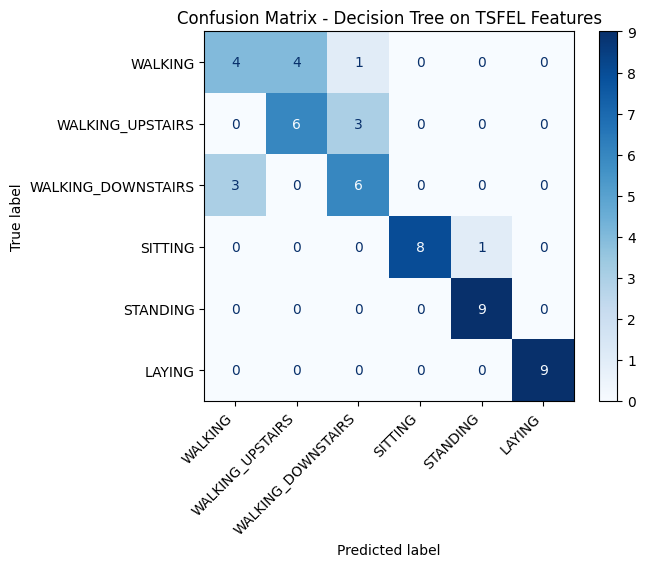

In [20]:
y_predtsfel = tsfeltree.predict(ts_features_test)
Accuracy2 = accuracy_score(y_test3, y_predtsfel)
precision2 =  precision_score(y_test3, y_predtsfel, average='macro')
recall2 =  recall_score(y_test3, y_predtsfel, average='macro')
print("Accuracy:", Accuracy2)
print("Precision:",precision2)
print("Recall:",recall2)

# Plot confusion matrix
cm2 = confusion_matrix(y_test3, y_predtsfel)
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"])
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.title("Confusion Matrix - Decision Tree on TSFEL Features")
plt.show()

In [ ]:
import joblib
joblib.dump(tsfeltree, 'tsfel_decision_tree_model.pkl')

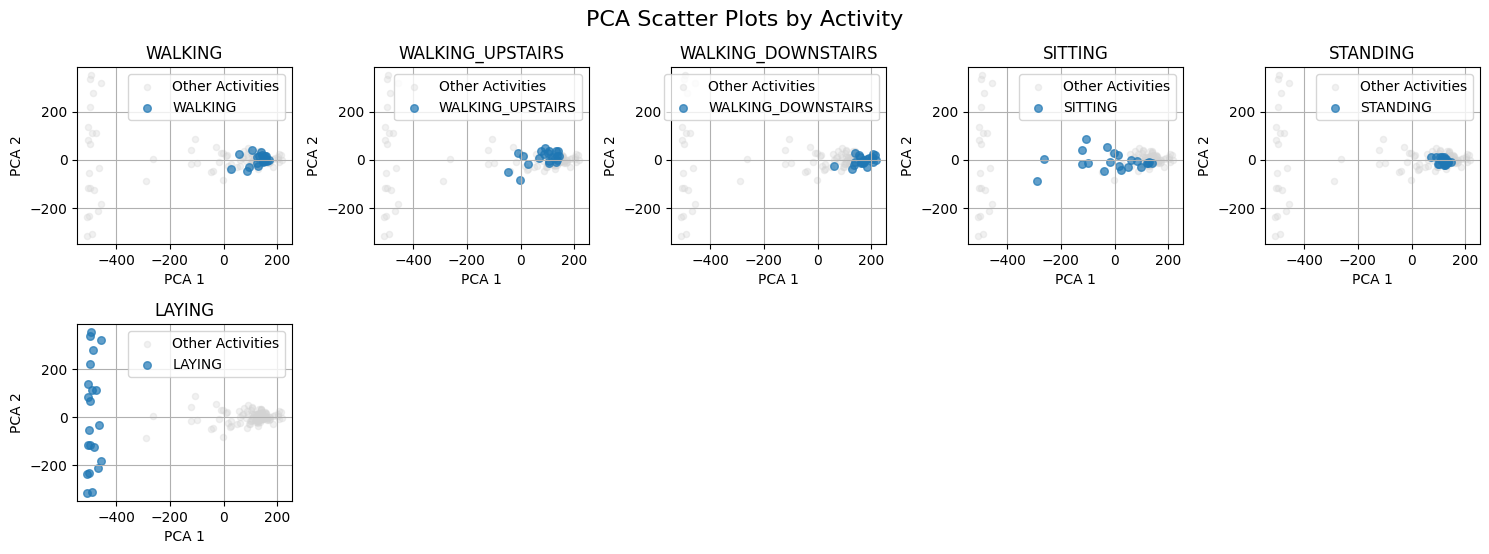

In [21]:
activity_names = {
    1:'WALKING', 2:'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS',
    4:'SITTING', 5:'STANDING', 6:'LAYING'
}

plt.figure(figsize=(15, 10))
for activity in range(1, 7):
    plt.subplot(4, 5, activity)
    mask = y_train3 == activity
    plt.scatter(ts_pca[~mask, 0], ts_pca[~mask, 1],
                c='lightgray', label='Other Activities', alpha=0.3, s=20)
    plt.scatter(ts_pca[mask, 0], ts_pca[mask, 1], c='tab:blue', label=activity_names[activity], alpha=0.7,s =30)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(f'{activity_names[activity]}')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.suptitle('PCA Scatter Plots by Activity', fontsize=16, y=1.02)
plt.show()


##c. Given Features in dataset

In [22]:
train_featpath = "/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/train"
test_featpath = "/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/test"

In [23]:
X_train_feat = pd.read_csv(f"{train_path}/X_train.txt", delim_whitespace=True, header=None)
X_test_feat = pd.read_csv(f"{test_path}/X_test.txt", delim_whitespace=True, header=None)

# Load the labels
y_train_feat = pd.read_csv(f"{train_path}/y_train.txt", delim_whitespace=True, header=None).values.ravel()
y_test_feat = pd.read_csv(f"{test_path}/y_test.txt", delim_whitespace=True, header=None).values.ravel()

/tmp/ipython-input-3484625730.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train_feat = pd.read_csv(f"{train_path}/X_train.txt", delim_whitespace=True, header=None)
/tmp/ipython-input-3484625730.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test_feat = pd.read_csv(f"{test_path}/X_test.txt", delim_whitespace=True, header=None)
/tmp/ipython-input-3484625730.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train_feat = pd.read_csv(f"{train_path}/y_train.txt", delim_whitespace=True, header=None).values.ravel()
/tmp/ipython-input-3484625730.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` in

In [24]:
X_train_feat

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


#### feat decision tree

In [25]:
feat_tree = DecisionTreeClassifier(random_state = 42)
feat_tree.fit(X_train_feat,y_train_feat)

DecisionTreeClassifier(random_state=42)

In [26]:
y_pred_feat = feat_tree.predict(X_test_feat)

#### results,confusion matrix

Accuracy: 0.8622327790973872
Precision: 0.8624733067496783
Recall: 0.8586831847358827


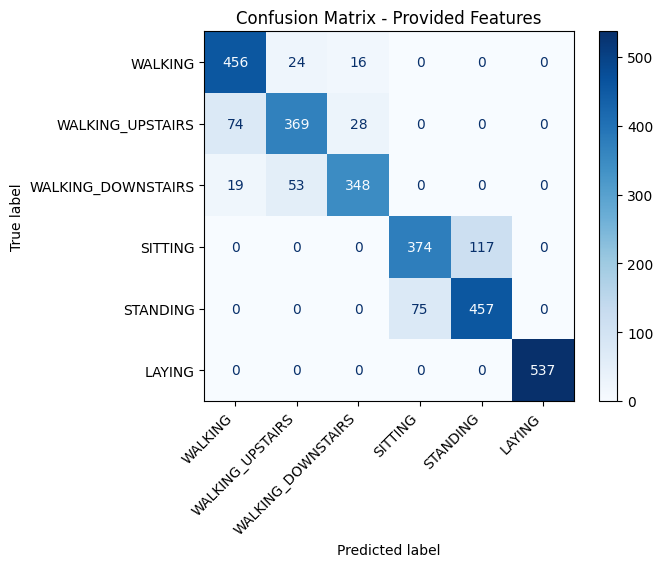

In [27]:
# Metrics
accuracy3 = accuracy_score(y_test_feat, y_pred_feat)
precision3 = precision_score(y_test_feat, y_pred_feat, average='macro')
recall3 = recall_score(y_test_feat, y_pred_feat, average='macro')
cm3 = confusion_matrix(y_test_feat, y_pred_feat)

# Print metrics
print("Accuracy:", accuracy3)
print("Precision:", precision3)
print("Recall:", recall3)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=[
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Provided Features")
plt.xticks(rotation=45, ha='right')
plt.show()


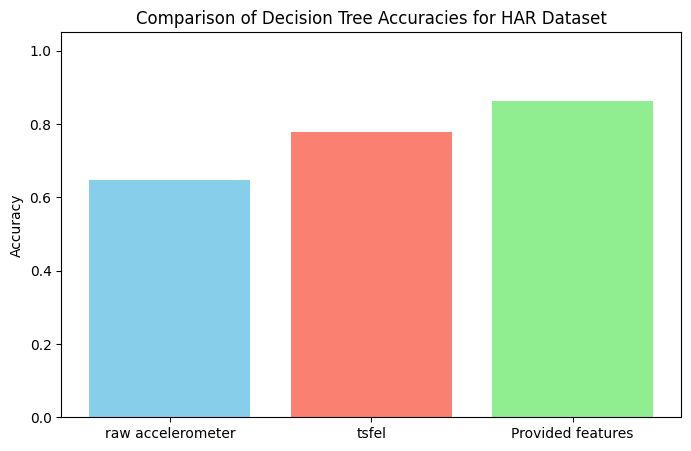

In [99]:
import matplotlib.pyplot as plt

model_names = ["raw accelerometer",'tsfel','Provided features']
accuracies = [Accuracy1,Accuracy2,accuracy3]
precision =[precision1,precision2,precision3]
recall =[recall1,recall2,recall3]

#accuracy plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Comparison of Decision Tree Accuracies for HAR Dataset')
plt.show()

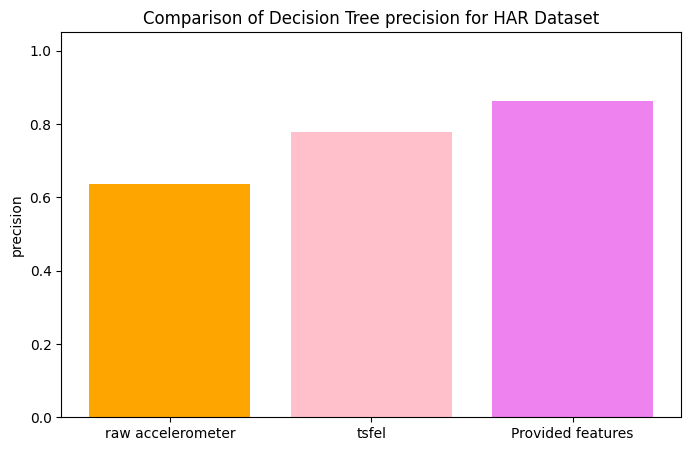

In [100]:
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, precision, color=['orange', 'pink', 'violet'])
plt.ylim(0, 1.05)
plt.ylabel('precision')
plt.title('Comparison of Decision Tree precision for HAR Dataset')
plt.show()

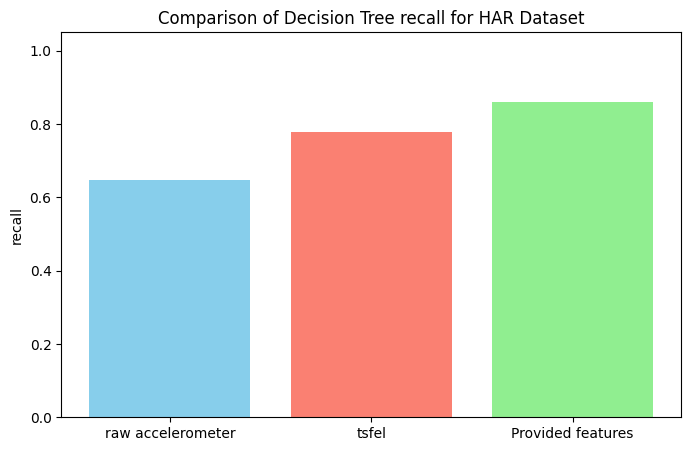

In [101]:
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, recall, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1.05)
plt.ylabel('recall')
plt.title('Comparison of Decision Tree recall for HAR Dataset')
plt.show()

# 2.Decision trees with varying depths


### raw accelerometer

In [102]:
depths = range(2,9)
accuracies_raw = []
for depth in depths:
  tree_raw = DecisionTreeClassifier(max_depth =depth,random_state = 42)
  tree_raw.fit(X_train_down_flat,y_train3)
  y_predraw = tree_raw.predict(X_test_down_flat)
  acc = accuracy_score(y_test3,y_predraw)
  accuracies_raw.append(acc)

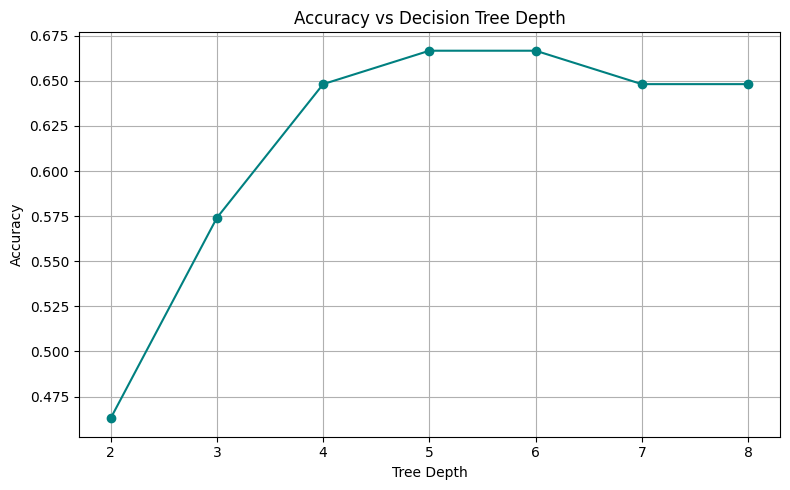

In [103]:
plt.figure(figsize=(8, 5))
plt.plot(depths, accuracies_raw, marker='o', color='teal')
plt.title('Accuracy vs Decision Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.grid(True)
plt.tight_layout()
plt.show()

### feature decision tree

In [33]:
depths = range(2,9)
accuracies_feature = []
for depth in depths:
  tree_feature = DecisionTreeClassifier(max_depth =depth,random_state = 42)
  tree_feature.fit(X_train_feat,y_train_feat)
  y_predfeature = tree_feature.predict(X_test_feat)
  acc = accuracy_score(y_test_feat,y_predfeature)
  accuracies_feature.append(acc)

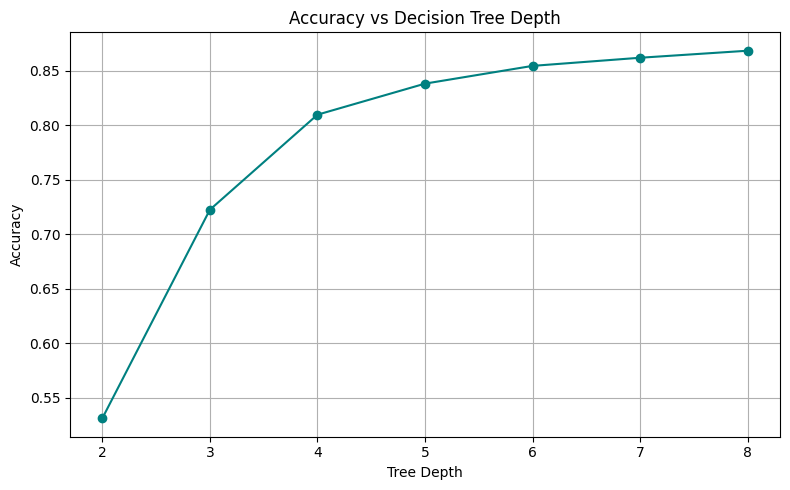

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(depths, accuracies_feature, marker='o', color='teal')
plt.title('Accuracy vs Decision Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.grid(True)
plt.tight_layout()
plt.show()

### tsfel model

In [35]:
depths = range(2,9)
accuracies_tsfel = []
for depth in depths:
  tree_tsfel2 = DecisionTreeClassifier(max_depth =depth,random_state = 42)
  tree_tsfel2.fit(ts_features,y_train3)
  y_predtsfels = tree_tsfel2.predict(ts_features_test)
  acc = accuracy_score(y_test3,y_predtsfels)
  accuracies_tsfel.append(acc)

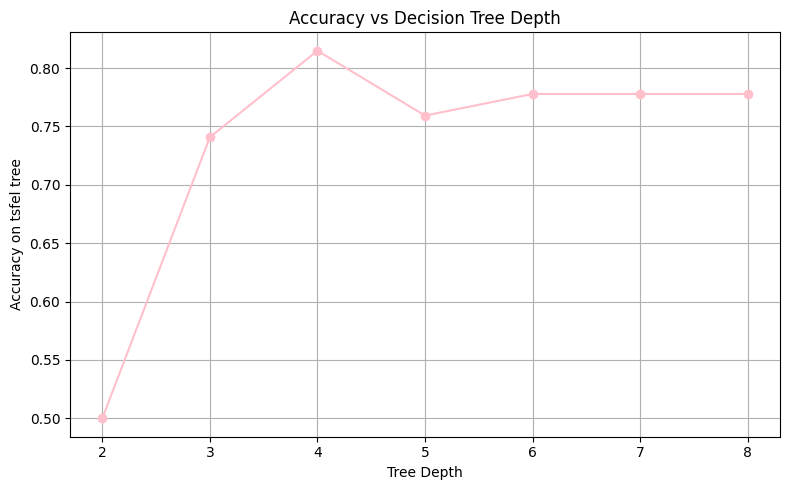

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(depths, accuracies_tsfel, marker='o', color='pink')
plt.title('Accuracy vs Decision Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy on tsfel tree')
plt.xticks(depths)
plt.grid(True)
plt.tight_layout()
plt.show()

##Activity wise test accuracy

In [104]:
from sklearn.metrics import classification_report

In [105]:
labels = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
          "SITTING", "STANDING", "LAYING"]

In [107]:
classacc_raw = cm.diagonal() / cm.sum(axis=1)        ###Raw accelerometer decsion tree accuracy findings
for i,acc in enumerate(classacc_raw):
  print(f"{labels[i]}: {acc:.3f}")

WALKING: 0.333
WALKING_UPSTAIRS: 0.333
WALKING_DOWNSTAIRS: 0.222
SITTING: 1.000
STANDING: 1.000
LAYING: 1.000


In [108]:
classacc_tsfel = cm2.diagonal()/cm2.sum(axis=1) ###tsfel decision treee accuracy findings
for i,acc in enumerate(classacc_tsfel):
  print(f"{labels[i]}: {acc:.3f}")


WALKING: 0.444
WALKING_UPSTAIRS: 0.667
WALKING_DOWNSTAIRS: 0.667
SITTING: 0.889
STANDING: 1.000
LAYING: 1.000


In [109]:
classacc_feature = cm3.diagonal()/cm3.sum(axis=1)   #feature dataset decision tree acc findings
for i,acc in enumerate(classacc_feature):
  print(f"{labels[i]}: {acc:.3f}")


WALKING: 0.919
WALKING_UPSTAIRS: 0.783
WALKING_DOWNSTAIRS: 0.829
SITTING: 0.762
STANDING: 0.859
LAYING: 1.000


### acuuracy comparison plots - activity wise -all models

# 3.Observation

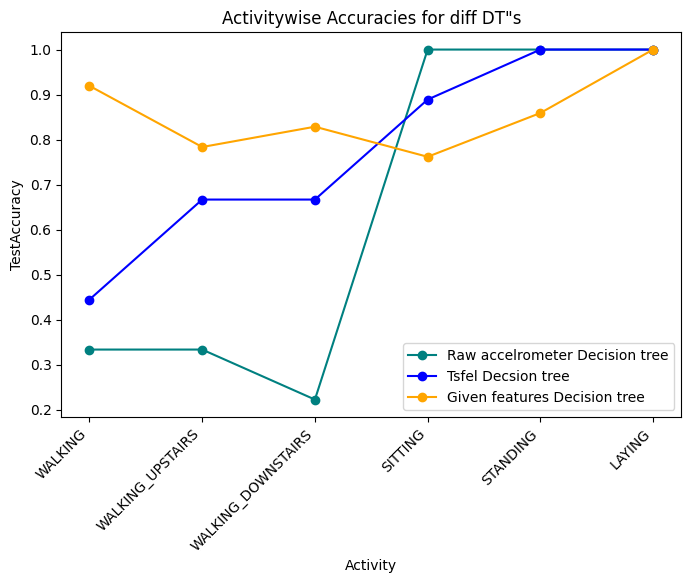

In [110]:
plt.figure(figsize=(8, 5))
plt.plot(labels, classacc_raw, marker='o', color='teal',label='Raw accelrometer Decision tree')
plt.plot(labels, classacc_tsfel, marker='o', color='blue',label='Tsfel Decsion tree')
plt.plot(labels,classacc_feature,marker = 'o',color = 'orange',label ='Given features Decision tree')
plt.title('Activitywise Accuracies for diff DT"s')
plt.xlabel('Activity')
plt.ylabel('TestAccuracy')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.show()

- We can observe that the **better performing activities** across all the models are ***"Sittting","Standing"&"laying"***.

- These activities have higher classification accuracy because they involve minimal movement which result in less variable time series
- In contrast , we observed that ,in **raw accelerometer model** ,where we have chosen to flatten the time series and fit it to the model ,we lost **valuable patterns of temporal data** that are essential to predict model that have movement like **walking_downstairs,walking-upstairs,walking**.
- In **tsfel model**,worst performing activity is still **"walking"**,It might be due to **walking motion is different between subject to subject**(like ,stride length,style ,pace etc).
- Walking also **share similar  temporal frequencies** and movements with **walking up and walking down** .Featues extracted by tsfel may not predict correctly  due to these subtle variations leading to misclassification.
- It can also be due to noise created during walking .

- In ** features model**,Sitting have the lowest accuracy.It might be because it creates **very similar sensor data to other static postures (laying,standing)if sensor placement doesnt capture the different orientation **.
- we also observed that most misclassifications happened among non static activities and among static activities.


In [119]:
X_train_flat = X_train.reshape(126, -1)
X_test_flat = X_test.reshape(54, -1)

In [121]:
Hartree1 = DecisionTreeClassifier(random_state=42)

In [122]:
Hartree1.fit(X_train_flat, y_train)

DecisionTreeClassifier(random_state=42)

In [123]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get unique subject IDs in the test set
unique_subjects = np.unique(subject_test)
subject_accuracies = {}

for subj in unique_subjects:
    idx = np.where(subject_test == subj)[0]
    y_true_subj = y_test[idx]
    X_subj = X_test_flat[idx]
    y_pred_subj = Hartree1.predict(X_subj)
    acc = accuracy_score(y_true_subj, y_pred_subj)
    subject_accuracies[subj] = acc

# Print results
for subj, acc in subject_accuracies.items():
    print(f"Subject {subj} accuracy: {acc:.2f}")


Subject Subject_10 accuracy: 0.67
Subject Subject_12 accuracy: 0.50
Subject Subject_13 accuracy: 0.67
Subject Subject_18 accuracy: 0.83
Subject Subject_2 accuracy: 0.67
Subject Subject_20 accuracy: 0.67
Subject Subject_24 accuracy: 0.50
Subject Subject_4 accuracy: 0.67
Subject Subject_9 accuracy: 0.67


### Subject wise accuracy of the model

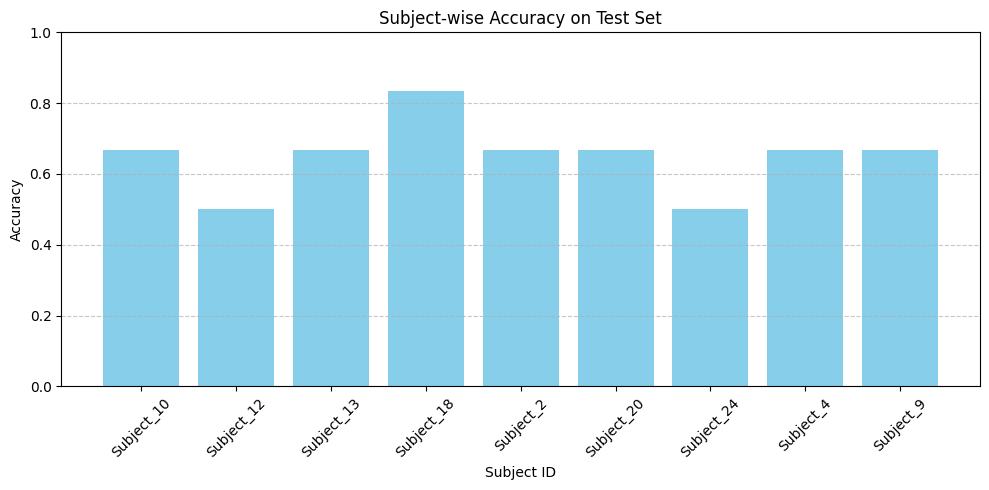

In [125]:
subjects = list(subject_accuracies.keys())
accuracies = list(subject_accuracies.values())

plt.figure(figsize=(10, 5))
plt.bar(subjects, accuracies, color='skyblue')
plt.xlabel("Subject ID")
plt.ylabel("Accuracy")
plt.title("Subject-wise Accuracy on Test Set")
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()